# This is a sample Jupyter Notebook

Below is an implementation of the project.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [14]:
# load
from sklearn.model_selection import train_test_split

train_path = ("data/mitbih_train.csv")
test_path = ("data/mitbih_test.csv")

train = pd.read_csv(train_path, header=None)
for i in range(train.shape[1]):
    train = train.rename(columns={train.columns[i]: str(i)})
train = train.rename(columns={train.columns[-1]: "label"})

test = pd.read_csv(test_path, header=None)
for i in range(test.shape[1]):
    test = test.rename(columns={test.columns[i]: str(i)})
test = test.rename(columns={test.columns[-1]: "label"})

# distribution
x_train_all = train.drop("label", axis=1)
y_train_all = train["label"]

x_train, x_val, y_train, y_val = train_test_split(
    x_train_all, y_train_all,
    test_size=0.2,
    random_state=1,
    stratify=y_train_all # dla klasyfikacji
)

x_test = test.drop("label", axis=1)
y_test = test["label"]

print(train.head())

print("train shape:", train.shape)
print("test shape :", test.shape)

          0         1         2         3         4         5         6  \
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.151961   
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.099715   
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.056757   
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.071823   
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.145540   

          7         8         9  ...  178  179  180  181  182  183  184  185  \
0  0.085784  0.058824  0.049020  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
1  0.088319  0.074074  0.082621  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
2  0.043243  0.054054  0.045946  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
3  0.060773  0.066298  0.058011  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
4  0.089202  0.117371  0.150235  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

   186  label  
0  0.0    0.0  
1  0.0    0.0  
2  0.0    0.0  
3  0

In [15]:
x_train.info()

procent_null = 100 * x_train.isnull().sum().sum() / x_train.size
print(f"Procent brakujacych danych: {procent_null:.2f}%")

<class 'pandas.core.frame.DataFrame'>
Index: 70043 entries, 4019 to 78219
Columns: 187 entries, 0 to 186
dtypes: float64(187)
memory usage: 100.5 MB
Procent brakujacych danych: 0.00%


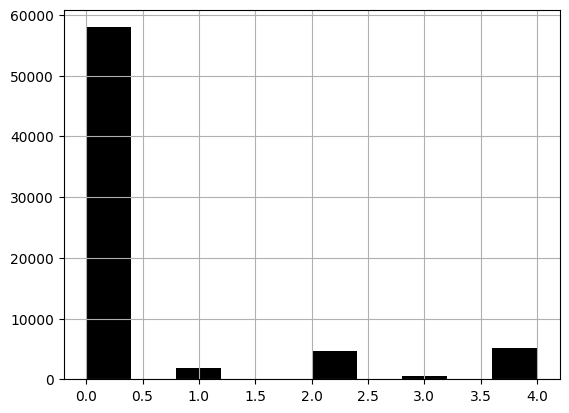

In [16]:
y_train.hist(bins = 10, color='black')
plt.show()

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

proc_pipeline = Pipeline(steps=[
    ('std_scaler', StandardScaler()),
])

column_transformer = ColumnTransformer([
    ('num', proc_pipeline, x_train.columns),
])

preprocessor = Pipeline(steps=[
    ('column_transformer', column_transformer),
])

x_ready = preprocessor.fit_transform(x_train)
print(x_ready)

[[ 0.0897241   0.05878623 -1.25249221 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.45486063  0.45814731  0.65514626 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.45486063 -0.09558988 -0.13297176 ... -0.09168416 -0.08887797
  -0.08729329]
 ...
 [ 0.01591676  0.59744286  0.60739866 ... -0.09168416 -0.08887797
  -0.08729329]
 [ 0.33975433 -0.07919169 -1.00109742 ... -0.09168416 -0.08887797
  -0.08729329]
 [-2.30351151 -1.36405471  0.93323734 ... -0.09168416 -0.08887797
  -0.08729329]]


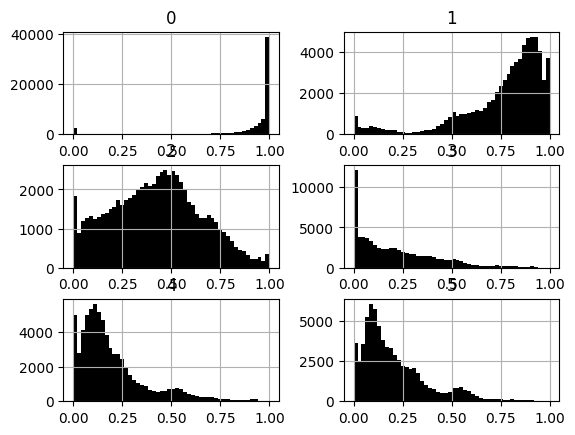

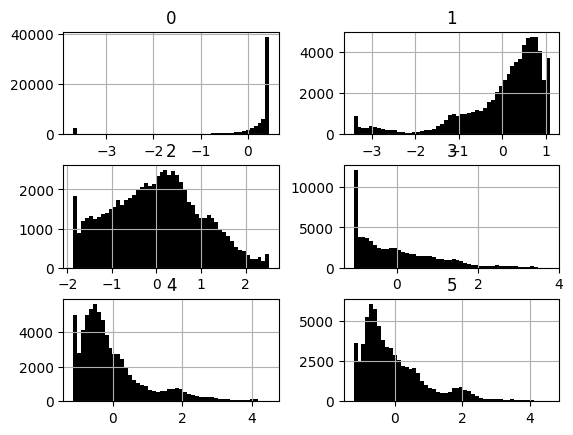

In [18]:
col = x_train.columns[:6]

x_train[col].hist(bins = 50, color='black')
plt.show()

x_ready_df = pd.DataFrame(x_ready, columns=x_train.columns)
x_ready_df[col].hist(bins = 50, color='black')
plt.show()

In [19]:
print("Before:")
print(x_train.iloc[:, :3].mean(), x_train.iloc[:, :3].std())

print("After:")
print(x_ready_df.iloc[:, :3].mean(), x_ready_df.iloc[:, :3].std())

Before:
0    0.890508
1    0.758111
2    0.424135
dtype: float64 0    0.240717
1    0.221705
2    0.227413
dtype: float64
After:
0    1.450646e-17
1    1.383693e-16
2   -4.950457e-17
dtype: float64 0    1.000007
1    1.000007
2    1.000007
dtype: float64


In [27]:
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000, # wydawalo warning na 100, ze nie znalazlo plateau
        class_weight='balanced' # bo mamy dyzbalans klasów
    )),
])

sgd_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDClassifier(
        class_weight='balanced',
        loss="log_loss" # domyslnie loss="hinge"
    )),
])

forest_class = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
    )),
])

start_time = time.time()
log_reg.fit(x_train, y_train)
log_pred = log_reg.predict(x_train)
log_proba = log_reg.predict_proba(x_train) # dla nll
end_time = time.time()
print("Czas log_reg: ", end_time - start_time)

start_time = time.time()
sgd_class.fit(x_train, y_train)
sgd_pred = sgd_class.predict(x_train)
sgd_proba = sgd_class.predict_proba(x_train)
end_time = time.time()
print("Czas sgd_class: ", end_time - start_time)

start_time = time.time()
forest_class.fit(x_train, y_train)
forest_pred = forest_class.predict(x_train)
forest_proba = forest_class.predict_proba(x_train)
end_time = time.time()
print("Czas forest_class: ", end_time - start_time)

Czas log_reg:  28.618454456329346
Czas sgd_class:  26.870251655578613
Czas forest_class:  65.14448618888855


In [28]:
print("NLL dla LogisticRegression: ", log_loss(y_train, log_proba))
print("NLL dla SGDClassifier: ", log_loss(y_train, sgd_proba))
print("NLL dla RandomForestClassifier: ", log_loss(y_train, forest_proba))

NLL dla LogisticRegression:  0.8551194591568552
NLL dla SGDClassifier:  0.4176328220006815
NLL dla RandomForestClassifier:  0.02162699112374716


Number of normal:  57977
Number of supraventricular ectopic beat:  1778
Number of ventricular ectopic beat:  4630
Number of fusion beat:  513
Number of nieokreślone / paced beat:  5145

Dla LogisticRegression
Confusion Matrix:



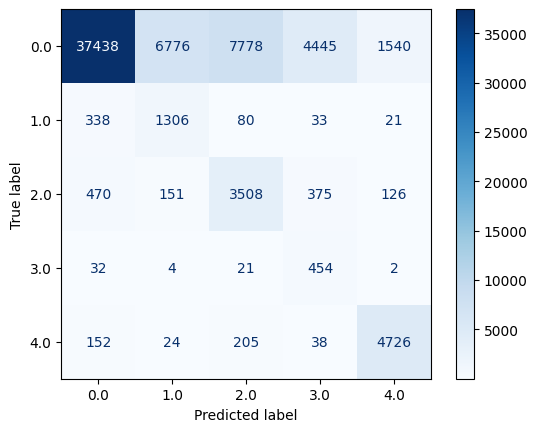

makro-F1 score:  0.48839974269212183
Dla SGDClassifier
Confusion Matrix:



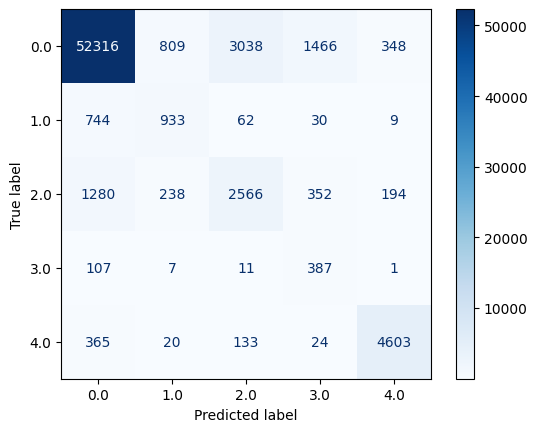

makro-F1 score:  0.6170511729708623
Dla RandomForestClassifier
Confusion Matrix:



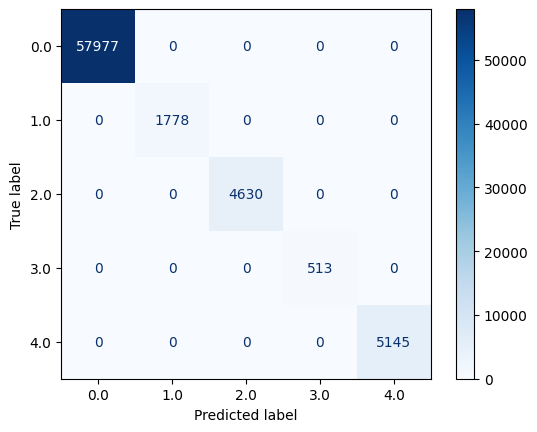

makro-F1 score:  1.0
Dla RandomForestClassifier na walidacyjnym
Confusion Matrix:



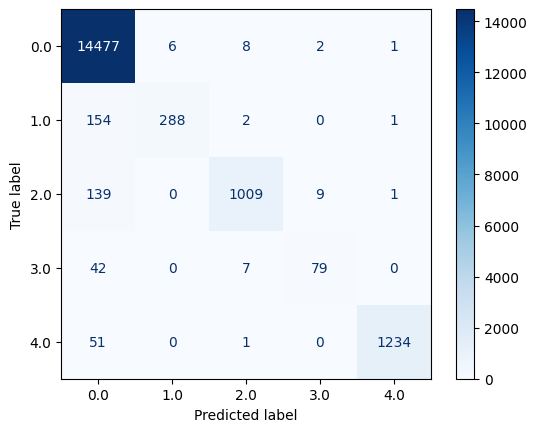

makro-F1 score:  0.8784490189680907


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
classes = np.unique(y_train)

print("Number of normal: ", (y_train == 0).sum())
print("Number of supraventricular ectopic beat: ", (y_train == 1).sum())
print("Number of ventricular ectopic beat: ", (y_train == 2).sum())
print("Number of fusion beat: ", (y_train == 3).sum())
print("Number of nieokreślone / paced beat: ", (y_train == 4).sum())

print("\nDla LogisticRegression")
print("Confusion Matrix:\n")
log_reg_cm = confusion_matrix(y_train, log_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=log_reg_cm, display_labels=classes)
disp1.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, log_pred, average='macro'))

print("Dla SGDClassifier")
print("Confusion Matrix:\n")
sgd_cm = confusion_matrix(y_train, sgd_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=sgd_cm, display_labels=classes)
disp2.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, sgd_pred, average='macro'))

print("Dla RandomForestClassifier")
print("Confusion Matrix:\n")
forest_cm = confusion_matrix(y_train, forest_pred)
disp3 = ConfusionMatrixDisplay(confusion_matrix=forest_cm, display_labels=classes)
disp3.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_train, forest_pred, average='macro'))

forest_pred_val  = forest_class.predict(x_val)
print("Dla RandomForestClassifier na walidacyjnym") # dla sprawdzenia
print("Confusion Matrix:\n")
forest_cm_2 = confusion_matrix(y_val, forest_pred_val)
disp4 = ConfusionMatrixDisplay(confusion_matrix=forest_cm_2, display_labels=classes)
disp4.plot(cmap='Blues')
plt.show()
print("makro-F1 score: ", f1_score(y_val, forest_pred_val, average='macro'))